In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../data/processed/featured_data.csv")

1. RISK SCORE vs CHURN (Customer Segmentation)

<Axes: xlabel='Churn', ylabel='Risk_Score'>

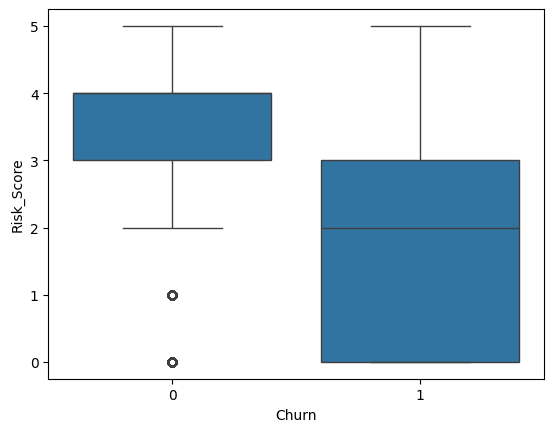

In [5]:
sns.boxplot(x='Churn', y='Risk_Score', data=df)

2. AGE GROUP RISK vs CHURN

<Axes: xlabel='Age_Group_Risk'>

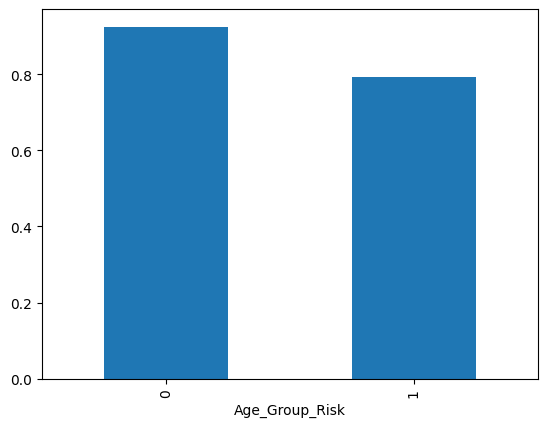

In [6]:
df.groupby('Age_Group_Risk')['Churn'].mean().plot(kind='bar')

DAMAGE + VEHICLE COMBO (VERY POWERFUL)

<Axes: xlabel='Damage_Vehicle'>

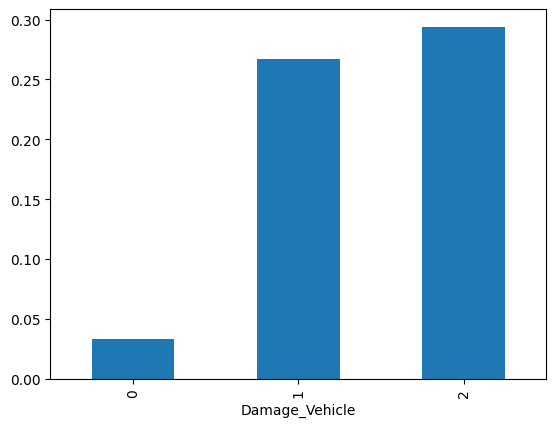

In [23]:
df.groupby('Damage_Vehicle')['Churn'].mean().plot(kind='bar')

4. PREMIUM PER DAY vs CHURN


<Axes: xlabel='Churn', ylabel='Premium_Per_Day'>

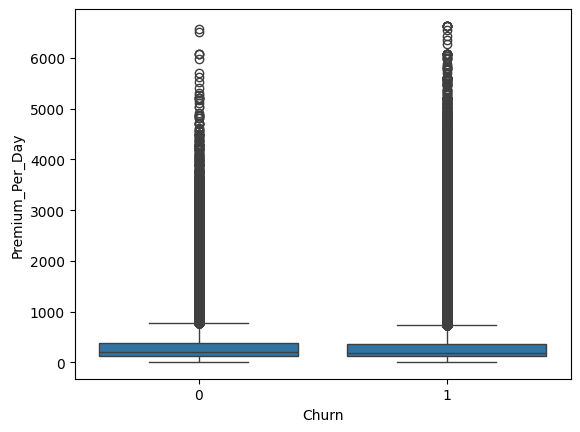

In [8]:
sns.boxplot(x='Churn', y='Premium_Per_Day', data=df)

5. LOG PREMIUM DISTRIBUTION


<Axes: xlabel='Premium_Log', ylabel='Count'>

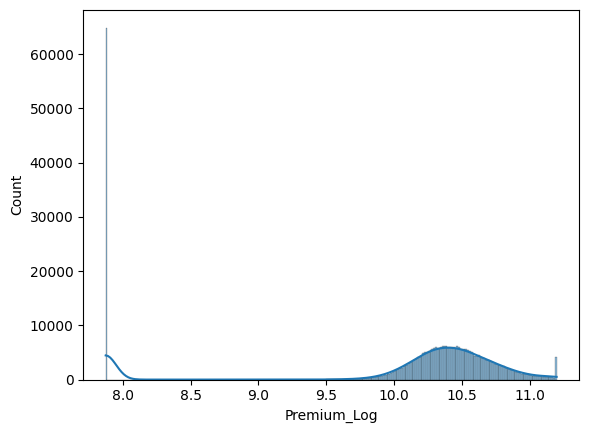

In [9]:
sns.histplot(df['Premium_Log'], kde=True)

6. HIGH RISK CUSTOMER vs CHURN

<Axes: xlabel='High_Risk_Customer'>

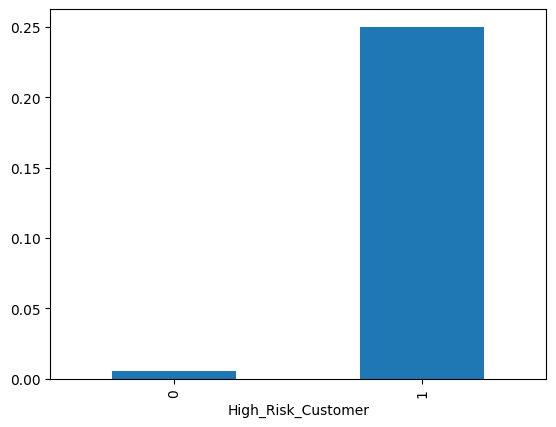

In [24]:
df.groupby('High_Risk_Customer')['Churn'].mean().plot(kind='bar')

7. NEW CUSTOMER vs CHURN


<Axes: xlabel='Is_New_Customer'>

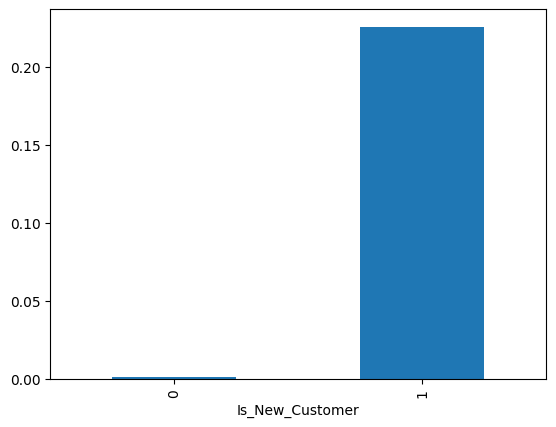

In [25]:
df.groupby('Is_New_Customer')['Churn'].mean().plot(kind='bar')

8. REGION FREQUENCY vs CHURN

<Axes: xlabel='Churn', ylabel='Region_Frequency'>

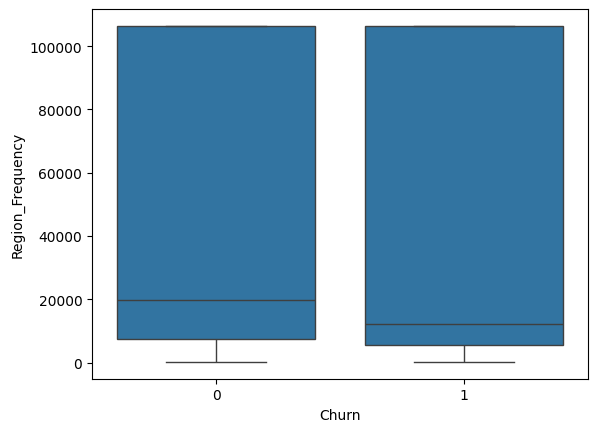

In [12]:
sns.boxplot(x='Churn', y='Region_Frequency', data=df)

9. CHANNEL FREQUENCY vs CHURN

<Axes: xlabel='Churn', ylabel='Channel_Frequency'>

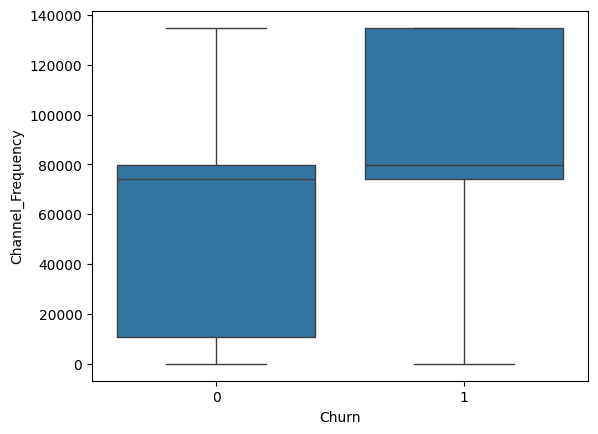

In [13]:
sns.boxplot(x='Churn', y='Channel_Frequency', data=df)

In [14]:
corr = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(corr)

Churn                   1.000000
Previously_Insured      0.341170
Engagement_Score        0.297657
Channel_Frequency       0.145496
Policy_Sales_Channel    0.139042
Vintage                 0.001050
Premium_Log            -0.002464
Premium_Per_Day        -0.009296
Driving_License        -0.010155
Region_Code            -0.010570
Customer_Value         -0.022447
Annual_Premium         -0.022487
Age                    -0.111147
Region_Frequency       -0.120662
Age_Vehicle            -0.172553
Age_Group_Risk         -0.193240
Vehicle_Age_Num        -0.221874
Damage_Vehicle         -0.335212
Is_New_Customer        -0.341170
Has_Damage             -0.354400
Risk_Score             -0.367138
High_Risk_Customer     -0.372801
Name: Churn, dtype: float64


CONVERSION RATE

In [15]:
pd.crosstab(df['High_Risk_Customer'], df['Churn'], normalize='index')

Churn,0,1
High_Risk_Customer,,
0,0.005377,0.994623
1,0.250105,0.749895


<Axes: xlabel='Risk_Score', ylabel='Premium_Per_Day'>

c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


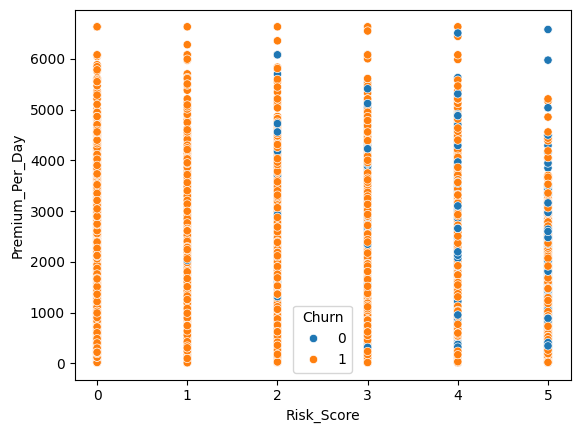

In [16]:
sns.scatterplot(x='Risk_Score', y='Premium_Per_Day', hue='Churn', data=df)

In [17]:
df['Churn'].value_counts(normalize=True)

Churn
1    0.877437
0    0.122563
Name: proportion, dtype: float64

In [18]:
df['Churn'] = df['Churn'].map({0:1, 1:0})

In [19]:
df.groupby('High_Risk_Customer')['Churn'].mean()
df.groupby('Damage_Vehicle')['Churn'].mean()
df.groupby('Is_New_Customer')['Churn'].mean()
df.groupby('Policy_Sales_Channel')['Churn'].mean()

Policy_Sales_Channel
1.0      0.032588
2.0      0.250000
3.0      0.304015
4.0      0.200393
6.0      0.000000
           ...   
157.0    0.268402
158.0    0.274390
159.0    0.019608
160.0    0.021810
163.0    0.304183
Name: Churn, Length: 155, dtype: float64

In [20]:
df.groupby('Policy_Sales_Channel')['Churn'].mean().sort_values(ascending=False).head(10)

Policy_Sales_Channel
43.0     1.000000
123.0    1.000000
28.0     0.333333
27.0     0.333333
36.0     0.326923
155.0    0.320097
163.0    0.304183
3.0      0.304015
121.0    0.296875
81.0     0.285714
Name: Churn, dtype: float64

In [21]:
channel_perf = df.groupby('Policy_Sales_Channel').agg(
    conversion_rate=('Churn','mean'),
    count=('Churn','size')
).sort_values(by='conversion_rate', ascending=False)

channel_perf.head(10)

,conversion_rate,count
Policy_Sales_Channel,,
43.0,1.000000,1
123.0,1.000000,1
28.0,0.333333,3
27.0,0.333333,3
36.0,0.326923,52
155.0,0.320097,1234
163.0,0.304183,2893
3.0,0.304015,523
121.0,0.296875,64


<Axes: xlabel='Policy_Sales_Channel'>

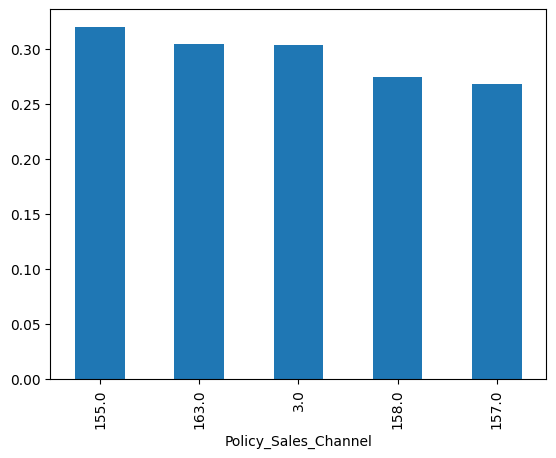

In [22]:
filtered = channel_perf[channel_perf['count'] > 100]

filtered.sort_values('conversion_rate', ascending=False)\
        .head(5)['conversion_rate']\
        .plot(kind='bar')